<h1 style="font-size: 42px; text-align: center;">HW5: Monte Carlo Tree Search & Naive Search</h1>

> **Full Name:** `Amirhosein Rezaei`  
> **Student ID:** `401105989`

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand the **theoretical foundations** of Monte Carlo Tree Search (MCTS) and how it differs from naive (brute-force) lookahead.
2. Be able to **implement MuZero-style learned dynamics** for planning without a known environment model.
3. Combine learned representation, dynamics, and prediction networks with tree search.
4. Compare empirical performance of **MCTS vs. naive depth search vs. no search** on `CartPole-v0`.

---

## 📚 Why Search Matters in Reinforcement Learning

Classical model-free RL (e.g., DQN, PPO) directly maps observations to actions. While powerful, these methods don't *plan*.
Classical model-based RL plans using a **given** simulator. But what if the simulator is unavailable or too expensive?

**MuZero** (Schrittwieser et al., 2019) solves this by *learning* a model in a latent space, then planning with MCTS in that latent space. This achieved state-of-the-art on Atari, Go, Chess, and Shogi with a single algorithm.

This notebook is a minimal but faithful implementation of these ideas on CartPole.

> 🧠 **What you must implement** is marked clearly with `# TODO`. Everything else (data plumbing, training loop scaffolding, plots) is provided.

## 📖 Part 1 — Theoretical Background

### 1.1 Monte Carlo Tree Search (MCTS)

MCTS builds a search tree incrementally by performing $N$ simulations from the root. Each simulation consists of four phases:

| Phase | Description |
|-------|-------------|
| **Selection** | Starting at the root, repeatedly choose children using a tree policy (PUCT/UCB) until reaching a leaf. |
| **Expansion** | At the leaf, query the dynamics + prediction networks to create child nodes for each action. |
| **Simulation/Evaluation** | Instead of random rollouts (classical MCTS), MuZero uses the value head directly. |
| **Backpropagation** | Propagate the value estimate back along the visited path, updating visit counts and Q-values. |

#### The PUCT formula (used by MuZero / AlphaZero)

At each internal node, the action chosen is:

$$a^* = \arg\max_a \Big[ Q(s, a) + P(s, a) \cdot \frac{\sqrt{N(s)}}{1 + N(s, a)} \cdot \Big( c_1 + \log \frac{N(s) + c_2 + 1}{c_2} \Big) \Big]$$

where:
- $Q(s,a)$ = mean value backed up through edge $(s,a)$
- $P(s,a)$ = prior probability from the prediction network
- $N(s)$, $N(s,a)$ = visit counts at the node and edge
- $c_1 = 1.25$, $c_2 = 19652$ (standard MuZero hyperparameters)

The Q-values are **min-max normalized** across the tree to keep the formula well-scaled across different reward magnitudes.

### 1.2 Naive Depth Search

Naive search enumerates **every** action sequence of length $d$. For action space $|A|$ and depth $d$, the cost is $O(|A|^d)$. For each leaf, we compute:

$$\text{Return}(a_1, \dots, a_d) = \sum_{t=0}^{d-1} \gamma^t r_t + \gamma^d V(s_d)$$

and pick the first action of the best sequence.

### 1.3 MuZero's Three Networks

| Network | Signature | Purpose |
|---------|-----------|---------|
| **Representation** $h_\theta$ | $o \mapsto s_0$ | Encode raw observation into latent state |
| **Dynamics** $g_\theta$ | $(s_t, a_t) \mapsto (s_{t+1}, r_t)$ | Predict next latent state and reward |
| **Prediction** $f_\theta$ | $s_t \mapsto (\pi_t, v_t)$ | Predict policy prior and value |

All three are trained **jointly end-to-end** by unrolling the model for $K$ steps and matching predictions to targets stored in a replay buffer.

### 1.4 Loss Function (MuZero)

For a sampled sub-trajectory unrolled $K$ steps:

$$\mathcal{L}(\theta) = \sum_{k=0}^{K} \Big[ \mathcal{L}^p(\pi^{\text{MCTS}}_k, \pi^\theta_k) + \mathcal{L}^v(z_k, v^\theta_k) + \mathcal{L}^r(u_k, r^\theta_k) \Big]$$

where $z_k$ is the n-step return target and $u_k$ the observed reward.

> ⚠️ **Common pitfall:** Use **MSE** for scalar value/reward targets, and **cross-entropy** between distributions for the policy.

## 🛠️ Part 2 — Step-by-Step Implementation Guide

The notebook is organized as follows. Sections marked **(provided)** require no implementation; sections marked **(TODO)** are for you to complete.

1. **Imports & Setup** *(provided)*
2. **Environment Wrapper** *(provided)*
3. **Replay Buffer** — *(partial TODO: n-step return computation)*
4. **Neural Networks** — *(TODO: all three networks)*
5. **Search Algorithms**
   - MinMax Normalizer *(provided)*
   - Tree Node *(provided)*
   - **MCTS** *(TODO: selection, expansion, backprop, PUCT)*
   - **Naive depth search** *(TODO)*
6. **Agent** — *(TODO: act, initial_inference, recurrent_step)*
7. **Training Loop** *(provided, but you must wire your code in)*
8. **Comparison Experiment** *(provided)*

Let's go!

## 1️⃣ Imports & Setup *(provided)*

In [12]:
import math
import time
import random
import warnings
from collections import deque

import numpy as np
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
print(f"Using device: {device}")

Using device: cuda


## 2️⃣ Environment Wrapper *(provided)*

Stacks the last `history_len` observations into a single flat vector.

In [13]:
class FrameStackWrapper(gym.Wrapper):
    def __init__(self, env, history_len=3):
        super().__init__(env)
        self.history_len = history_len
        self.obs_dim = env.observation_space.shape[0]
        self.num_actions = env.action_space.n
        self.frames = deque(maxlen=history_len)

    def _stacked(self):
        stacked = np.zeros((self.history_len, self.obs_dim), dtype=np.float32)
        n = len(self.frames)
        if n > 0:
            stacked[self.history_len - n:] = np.array(self.frames)
        return stacked.flatten().reshape(1, -1)

    def reset(self):
        self.episode_return = 0.0
        self.frames.clear()
        obs = self.env.reset()
        self.frames.append(obs)
        return self._stacked()

    def step(self, action):
        next_obs, reward, done, info = self.env.step(action)
        self.frames.append(next_obs)
        self.episode_return += reward
        if done:
            info["return"] = self.episode_return
        return self._stacked(), reward, done, info


class EnvironmentRunner:
    """Runs an episode and collects a full trajectory."""
    def __init__(self, env):
        self.env = env
        self.num_actions = env.action_space.n
        self.episode_returns = []

    def run_episode(self, agent, max_steps=500):
        observations, actions, rewards, dones, policies, values = [], [], [], [], [], []
        obs = self.env.reset()
        observations.append(torch.tensor(obs, dtype=dtype))

        done = False
        steps = 0
        while not done and steps < max_steps:
            obs_t = torch.tensor(obs, dtype=dtype, device=device)
            action, policy, value = agent.act(obs_t)
            next_obs, reward, done, _ = self.env.step(action)

            observations.append(torch.tensor(next_obs, dtype=dtype))
            actions.append(int(action))
            policies.append(torch.tensor(policy, dtype=dtype))
            values.append(torch.tensor([float(value)], dtype=dtype))
            rewards.append(torch.tensor([float(reward)], dtype=dtype))
            dones.append(done)

            obs = next_obs
            steps += 1

        ep_return = float(sum(r.item() for r in rewards))
        self.episode_returns.append(ep_return)

        return {
            "obs": observations,
            "actions": actions,
            "rewards": rewards,
            "dones": dones,
            "policies": policies,
            "values": values,
            "length": len(observations),
        }

## 3️⃣ Replay Buffer

The scaffold is provided, but you must implement the **n-step return computation** inside `_sample_one`.

### What you need to compute

For each step $t$ in the sampled sub-trajectory, the n-step bootstrapped return is:

$$z_t = \sum_{i=0}^{n-1} \gamma^i r_{t+i} + \gamma^n V(s_{t+n})$$

If $t+n$ exceeds the trajectory length, the bootstrap value $V(s_{t+n})$ should be **0** (terminal). Be careful with index bounds!

In [14]:
class ReplayBuffer:
    def __init__(self, capacity, num_actions):
        self.capacity = capacity
        self.num_actions = num_actions
        self.memory = []
        self.position = 0

    def __len__(self):
        return len(self.memory)

    def add(self, trajectory):
        if len(self.memory) < self.capacity:
            self.memory.append(trajectory)
        else:
            self.memory[self.position] = trajectory
        self.position = (self.position + 1) % self.capacity

    def _sample_one(self, k, n, gamma):
        """
        Returns a dict with keys:
          - 'obs':     observation tensor at the start step
          - 'actions': list of length k (ints)
          - 'rewards': list of length k (each shape [1])
          - 'pi':      list of length k+1 (each shape [num_actions])
          - 'return':  list of length k+1 (each shape [1]) — the n-step targets

        The starting index is chosen uniformly at random in [0, T-1].
        """
        traj = self.memory[np.random.randint(len(self.memory))]
        T = traj["length"]
        last_idx = T - 1
        start = np.random.randint(T)

        obs = traj["obs"][start]
        returns, pis, action_list, rewards_list = [], [], [], []

        for step in range(start, start + k + 1):
            bootstrap_idx = step + n
            if bootstrap_idx >= last_idx:
                bootstrap_value = 0.0
            else:
                bootstrap_value = traj["values"][bootstrap_idx].item() * (gamma ** n)
            reward_sum = 0.0
            for i, r_idx in enumerate(range(step, min(last_idx, bootstrap_idx))):
                if r_idx < len(traj["rewards"]):
                    reward_sum += (gamma ** i) * traj["rewards"][r_idx].item()
            total = torch.tensor([reward_sum + bootstrap_value], dtype=dtype, device=device)
            returns.append(total)

            # Reward target (skip first step — reward corresponds to action taken)
            if step != start:
                if 0 < step <= last_idx and step - 1 < len(traj["rewards"]):
                    rewards_list.append(traj["rewards"][step - 1].to(device))
                else:
                    rewards_list.append(torch.zeros(1, dtype=dtype, device=device))

            # Policy target
            if 0 <= step < last_idx and step < len(traj["policies"]):
                pis.append(traj["policies"][step].to(device))
            else:
                pis.append(torch.full((self.num_actions,), 1.0 / self.num_actions,
                                      dtype=dtype, device=device))

        # Action sequence (length K)
        valid_end = min(last_idx - 1, start + k - 1)
        if valid_end >= start:
            action_list = list(traj["actions"][start:valid_end + 1])
        else:
            action_list = []
        while len(action_list) < k:
            action_list.append(np.random.randint(self.num_actions))

        return {
            "obs": obs,
            "actions": action_list,
            "rewards": rewards_list,
            "pi": pis,
            "return": returns,
        }

    def sample_batch(self, batch_size, k, n, gamma=0.99):
        return [self._sample_one(k, n, gamma) for _ in range(batch_size)]

## 4️⃣ Neural Networks (TODO)

Implement the three MuZero networks. Keep them small — CartPole is low-dimensional.

### Design constraints

- **Representation**: input `(B, input_dim)` → output `(B, hidden_dim)`.
- **Dynamics**: input is the concatenation of latent state and one-hot action: `(B, hidden_dim + num_actions)` → output `(next_state, reward)` where `reward.shape == (B,)`.
- **Prediction**: input `(B, hidden_dim)` → output `(policy, value)` where `policy` is a softmax distribution of shape `(B, num_actions)` and `value.shape == (B,)`.

Use 1–2 hidden layers (e.g., 128 units) and ReLU activations. A dropout layer is optional but helps generalization.

In [15]:
class RepresentationNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim, num_actions, dropout=0.1):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(hidden_dim + num_actions, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.state_head = nn.Sequential(
            nn.Linear(128, hidden_dim),
            nn.ReLU(),
        )
        self.reward_head = nn.Linear(128, 1)

    def forward(self, state_action):
        x = self.trunk(state_action)
        next_state = self.state_head(x)
        reward = self.reward_head(x).squeeze(-1)
        return next_state, reward


class PredictionNet(nn.Module):
    def __init__(self, hidden_dim, num_actions, dropout=0.1):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.policy_head = nn.Linear(128, num_actions)
        self.value_head = nn.Linear(128, 1)

    def forward(self, h):
        x = self.trunk(h)
        policy = F.softmax(self.policy_head(x), dim=-1)
        value = self.value_head(x).squeeze(-1)
        return policy, value

## 5️⃣ Search Algorithms

### 5.1 MinMax Normalizer *(provided)*

In [16]:
class MinMaxStats:
    """Running min/max tracker used to normalize Q-values inside MCTS."""
    def __init__(self):
        self.max = -float("inf")
        self.min = float("inf")

    def update(self, value):
        v = float(value)
        if v > self.max: self.max = v
        if v < self.min: self.min = v

    def normalize(self, value):
        v = float(value)
        if self.max > self.min:
            return (v - self.min) / (self.max - self.min)
        return v

### 5.2 Tree Node *(provided)*

In [17]:
class Node:
    """A node in the MCTS tree."""
    __slots__ = ("prior", "state", "reward", "children", "visits", "value_sum")

    def __init__(self, prior):
        self.prior = prior
        self.state = None        # latent state (torch tensor, detached)
        self.reward = 0.0        # reward received from parent transition
        self.children = {}       # action -> Node
        self.visits = 0
        self.value_sum = 0.0

    def expanded(self):
        return len(self.children) > 0

    def Q(self):
        return self.value_sum / self.visits if self.visits > 0 else 0.0

### 5.3 MCTS (TODO)

Implement the four MCTS phases. The class skeleton is provided; you must fill the four core methods.

#### High-level pseudocode

```
function run(N, root_state):
    root = make_root(root_state)
    add_dirichlet_noise(root)
    stats = MinMaxStats()

    repeat N times:
        path = [root]
        node = root
        # SELECTION
        while node.expanded():
            action, child = select_child(node)
            path.append(child)
            node = child

        # EXPANSION at leaf `node`, using parent = path[-2]
        leaf_value = expand(parent, leaf, chosen_action)

        # BACKPROPAGATION
        backpropagate(path, leaf_value)

    return visit_counts, root.Q()
```

#### PUCT score (for `_ucb`)

$$\text{score}(s,a) = Q(s,a)_{\text{norm}} + P(s,a) \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)} \cdot \Big( c_1 + \log \frac{N(s) + c_2 + 1}{c_2} \Big)$$

If the child has 0 visits, treat $Q$ as 0.

In [18]:
class MCTS:
    def __init__(self, num_actions, agent, gamma=0.99,
                 c1=1.25, c2=19652,
                 dirichlet_alpha=0.25, exploration_frac=0.25):
        self.num_actions = num_actions
        self.agent = agent
        self.gamma = gamma
        self.c1 = c1
        self.c2 = c2
        self.dirichlet_alpha = dirichlet_alpha
        self.exploration_frac = exploration_frac

    def run(self, num_simulations, root_state):
        # Initialize root with prior from prediction net
        with torch.no_grad():
            policy, _ = self.agent.pred_net(root_state)
        policy = policy.detach().cpu().numpy().flatten()

        root = Node(prior=0.0)
        root.state = root_state.detach()
        for a in range(self.num_actions):
            root.children[a] = Node(prior=float(policy[a]))
        self._add_dirichlet_noise(root)

        stats = MinMaxStats()

        for _ in range(num_simulations):
            path = [root]
            node = root
            last_action = None

            while node.expanded():
                action, child = self._select_child(node, stats)
                last_action = action
                path.append(child)
                node = child

            parent = path[-2] if len(path) > 1 else root
            if last_action is None:
                last_action = np.random.randint(self.num_actions)
            leaf_value = self._expand(parent, node, last_action)
            self._backpropagate(path, leaf_value, stats)

        visit_counts = np.array([root.children[a].visits for a in range(self.num_actions)],
                                dtype=np.float32)
        return visit_counts, root.Q()

    def _select_child(self, parent, stats):
        """Return (best_action, best_child) using PUCT."""
        best_score = -float("inf")
        best_action = None
        best_child = None
        for action, child in parent.children.items():
            score = self._ucb(parent, child, stats)
            if score > best_score:
                best_score = score
                best_action = action
                best_child = child
        return best_action, best_child

    def _ucb(self, parent, child, stats):
        """Return PUCT score for a child edge."""
        pb_c = math.log((parent.visits + self.c2 + 1) / self.c2) + self.c1
        pb_c *= math.sqrt(parent.visits) / (1 + child.visits)
        prior_score = pb_c * child.prior
        if child.visits > 0:
            q = child.reward + self.gamma * child.Q()
            q = stats.normalize(q)
        else:
            q = 0.0
        return prior_score + q

    def _expand(self, parent, leaf, action):
        """Expand `leaf` by simulating one step of dynamics from `parent`.
        Returns the value estimate at the leaf."""
        action_t = torch.tensor([action], dtype=torch.long, device=device)
        with torch.no_grad():
            next_state, policy, value, reward = self.agent.recurrent_step(parent.state, action_t)

        leaf.state = next_state.detach()
        leaf.reward = float(reward.item())
        policy_np = policy.detach().cpu().numpy().flatten()
        for a in range(self.num_actions):
            leaf.children[a] = Node(prior=float(policy_np[a]))
        return float(value.item())

    def _backpropagate(self, path, value, stats):
        """Propagate `value` back up the path, updating visits, Q-values, and stats."""
        for node in reversed(path):
            node.value_sum += value
            node.visits += 1
            stats.update(node.reward + self.gamma * node.Q())
            value = node.reward + self.gamma * value

    def _add_dirichlet_noise(self, root):
        noise = np.random.dirichlet([self.dirichlet_alpha] * self.num_actions)
        frac = self.exploration_frac
        for a, n in zip(range(self.num_actions), noise):
            root.children[a].prior = root.children[a].prior * (1 - frac) + n * frac

### 5.4 Naive Depth Search (TODO)

Enumerate all $|A|^d$ action sequences and pick the first action of the best one.

#### Tips

- Use `torch.no_grad()` since we're not training the model during search.
- Maintain three things across depth steps:
  1. `states`: latent states for every partial sequence so far.
  2. `sequences`: numpy array of shape `(num_sequences, d+1)` storing the actions chosen.
  3. `cum_rewards`: running discounted sum of rewards.
- At each depth, expand `states` with `repeat_interleave` and extend `sequences` with all possible next actions.
- After the final step, the total return is `cum_rewards + gamma**depth * V(s_d)`.

In [19]:
@torch.no_grad()
def naive_depth_search(agent, root_state, num_actions, gamma, depth=3):
    """
    Returns:
      best_first_action (int): the first action of the best discovered sequence
      best_total_return (float): the corresponding return estimate
    """
    states = root_state.repeat(num_actions, 1)
    first_acts = np.arange(num_actions)
    sequences = first_acts.reshape(-1, 1)
    cum_rewards = torch.zeros(num_actions, device=device)
    last_values = torch.zeros(num_actions, device=device)

    for d in range(depth):
        last_actions = torch.tensor(sequences[:, -1], dtype=torch.long, device=device)
        next_states, _, values, rewards = agent.recurrent_step(states, last_actions)
        cum_rewards += (gamma ** d) * rewards.flatten()
        last_values = values.flatten()
        if d < depth - 1:
            states = next_states.repeat_interleave(num_actions, dim=0)
            sequences = np.repeat(sequences, num_actions, axis=0)
            extra = np.tile(np.arange(num_actions), len(sequences) // num_actions)
            sequences = np.hstack([sequences, extra.reshape(-1, 1)])
            cum_rewards = cum_rewards.repeat_interleave(num_actions)

    total = cum_rewards + (gamma ** depth) * last_values
    best = int(torch.argmax(total).item())
    return int(sequences[best, 0]), float(total[best].item())

## 6️⃣ Agent (TODO)

The agent ties the three networks together and exposes:

- `initial_inference(obs)` — encode the observation, then call the prediction net.
- `recurrent_step(state, action)` — one step of the learned model.
- `act(obs)` — pick an action using MCTS / naive / no search.

> ⚠️ Use `@torch.no_grad()` in `act` so action selection never leaks gradients.

In [20]:
class MuZeroAgent(nn.Module):
    def __init__(self, num_actions, rep_net, dyn_net, pred_net,
                 num_simulations=25, search_type="mcts",
                 gamma=0.99, naive_depth=3, temperature=1.0):
        super().__init__()
        self.num_actions = num_actions
        self.rep_net = rep_net
        self.dyn_net = dyn_net
        self.pred_net = pred_net
        self.gamma = gamma
        self.num_simulations = num_simulations
        self.search_type = search_type
        self.naive_depth = naive_depth
        self.temperature = temperature

        if search_type == "mcts":
            self.mcts = MCTS(num_actions, self, gamma=gamma)
        else:
            self.mcts = None

    def initial_inference(self, obs):
        """Encode an observation, then return (state, policy, value)."""
        state = self.rep_net(obs)
        policy, value = self.pred_net(state)
        return state, policy, value

    def recurrent_step(self, state, action):
        """One step of the learned dynamics.
        Returns (next_state, policy, value, reward).

        Notes:
          - `action` may be a python int, numpy array, or torch tensor.
          - One-hot encode the action and normalize by num_actions, then
            concatenate with `state` and pass through dyn_net.
        """
        if not isinstance(action, torch.Tensor):
            action = torch.tensor(action, dtype=torch.long, device=device)
        action = action.to(device)
        if action.dim() == 0:
            action = action.unsqueeze(0)

        batch_size = state.shape[0]
        one_hot = torch.zeros(batch_size, self.num_actions, dtype=dtype, device=device)
        one_hot.scatter_(1, action.view(-1, 1), 1.0)
        one_hot = one_hot / self.num_actions

        state_action = torch.cat([state, one_hot], dim=-1)
        next_state, reward = self.dyn_net(state_action)
        policy, value = self.pred_net(next_state)
        return next_state, policy, value, reward

    @torch.no_grad()
    def act(self, obs):
        """Choose an action. Returns (action_int, policy_array, value_float)."""
        state = self.rep_net(obs)

        if self.search_type == "mcts":
            visit_counts, root_value = self.mcts.run(self.num_simulations, state)
            if self.temperature == 0 or self.temperature < 1e-6:
                policy = np.zeros_like(visit_counts)
                policy[np.argmax(visit_counts)] = 1.0
            else:
                counts_temp = visit_counts ** (1.0 / self.temperature)
                policy = counts_temp / counts_temp.sum()
            action = int(np.random.choice(len(policy), p=policy))
            return action, policy, float(root_value)

        elif self.search_type == "naive":
            action, best_return = naive_depth_search(
                self, state, self.num_actions, self.gamma, depth=self.naive_depth
            )
            policy = np.zeros(self.num_actions, dtype=np.float32)
            policy[action] = 1.0
            return action, policy, float(best_return)

        else:
            policy_probs, value = self.pred_net(state)
            policy_np = policy_probs.detach().cpu().numpy().flatten()
            if self.temperature == 0 or self.temperature < 1e-6:
                action = int(np.argmax(policy_np))
                one_hot = np.zeros(self.num_actions, dtype=np.float32)
                one_hot[action] = 1.0
                return action, one_hot, float(value.item())
            policy_temp = policy_np ** (1.0 / self.temperature)
            policy_temp = policy_temp / policy_temp.sum()
            action = int(np.random.choice(len(policy_temp), p=policy_temp))
            return action, policy_temp, float(value.item())

## 7️⃣ Training Loop *(provided — uses your implementations)*

This is the standard MuZero training pipeline:

1. Collect one full episode.
2. Push it to the replay buffer.
3. Once enough trajectories are collected, do several gradient updates per episode:
   - Sample a batch of sub-trajectories.
   - Compute initial-step loss using `initial_inference`.
   - Unroll $K$ steps using `recurrent_step` and accumulate losses.
   - Backprop and update.
4. Anneal action-selection temperature.

### Loss recipe

- **Policy**: cross-entropy between predicted softmax and target distribution.
- **Value**: **MSE** between predicted scalar and n-step return.
- **Reward**: **MSE** between predicted reward and observed reward.

In [21]:
def cross_entropy_with_target(predicted_probs, target_probs, eps=1e-8):
    """Cross-entropy between two probability distributions."""
    return -(target_probs * torch.log(predicted_probs + eps)).sum(dim=-1).mean()


def train_agent(search_type="mcts", num_episodes=300, verbose=True):
    # Hyperparameters
    history_len = 3
    hidden_dim = 64
    num_simulations = 25
    naive_depth = 3
    replay_capacity = 300
    batch_size = 32
    K = 5
    N = 10
    lr = 1e-3
    gamma = 0.99
    value_coef = 1.0
    reward_coef = 1.0
    min_buffer_size = 15
    updates_per_episode = 16

    raw_env = gym.make("CartPole-v0")
    env = FrameStackWrapper(raw_env, history_len)
    obs_dim = raw_env.observation_space.shape[0]
    num_actions = raw_env.action_space.n
    input_dim = history_len * obs_dim

    rep_net = RepresentationNet(input_dim, hidden_dim).to(device)
    dyn_net = DynamicsNet(hidden_dim, num_actions).to(device)
    pred_net = PredictionNet(hidden_dim, num_actions).to(device)
    agent = MuZeroAgent(num_actions, rep_net, dyn_net, pred_net,
                        num_simulations=num_simulations,
                        search_type=search_type, gamma=gamma,
                        naive_depth=naive_depth).to(device)

    runner = EnvironmentRunner(env)
    buffer = ReplayBuffer(replay_capacity, num_actions)
    optimizer = torch.optim.Adam(agent.parameters(), lr=lr)

    for ep in range(num_episodes):
        # Temperature schedule
        if ep < num_episodes * 0.4:
            agent.temperature = 1.0
        elif ep < num_episodes * 0.7:
            agent.temperature = 0.5
        else:
            agent.temperature = 0.25

        # 1) Collect
        traj = runner.run_episode(agent)
        buffer.add(traj)
        if len(buffer) < min_buffer_size:
            continue

        # 2) Train
        for _ in range(updates_per_episode):
            batch = buffer.sample_batch(batch_size, K, N, gamma=gamma)

            obs_batch = torch.stack([b["obs"].flatten() for b in batch]).to(device).to(dtype)
            actions_batch = torch.tensor([b["actions"] for b in batch], dtype=torch.long, device=device)
            rewards_batch = torch.stack([torch.cat(b["rewards"]) for b in batch]).to(device)
            policies_batch = torch.stack([torch.stack(b["pi"]) for b in batch]).to(device)
            returns_batch = torch.stack([torch.cat(b["return"]) for b in batch]).to(device)

            optimizer.zero_grad()

            # Initial step
            state, policy, value = agent.initial_inference(obs_batch)
            policy_loss = cross_entropy_with_target(policy, policies_batch[:, 0])
            value_loss = F.mse_loss(value, returns_batch[:, 0])
            total_loss = policy_loss + value_coef * value_loss

            # K unroll steps
            for step in range(K):
                a = actions_batch[:, step]
                state, policy, value, reward = agent.recurrent_step(state, a)
                p_loss = cross_entropy_with_target(policy, policies_batch[:, step + 1])
                v_loss = F.mse_loss(value, returns_batch[:, step + 1])
                r_loss = F.mse_loss(reward, rewards_batch[:, step])
                total_loss = total_loss + (p_loss + value_coef * v_loss + reward_coef * r_loss) / K

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), max_norm=5.0)
            optimizer.step()

        if verbose and (ep + 1) % 25 == 0:
            clear_output(wait=True)
            recent = runner.episode_returns[-25:]
            print(f"[{search_type}] Episode {ep+1}/{num_episodes} | mean(last 25) = {np.mean(recent):.1f}")
            plt.figure(figsize=(8, 4))
            plt.plot(runner.episode_returns)
            plt.title(f"{search_type} — Episode {ep+1}")
            plt.xlabel("Episode"); plt.ylabel("Return")
            plt.grid(alpha=0.3)
            plt.show()

    return runner.episode_returns

## 8️⃣ Comparison Experiment *(provided)*

Train three agents and compare their learning curves.

[none] Episode 300/300 | mean(last 25) = 16.6


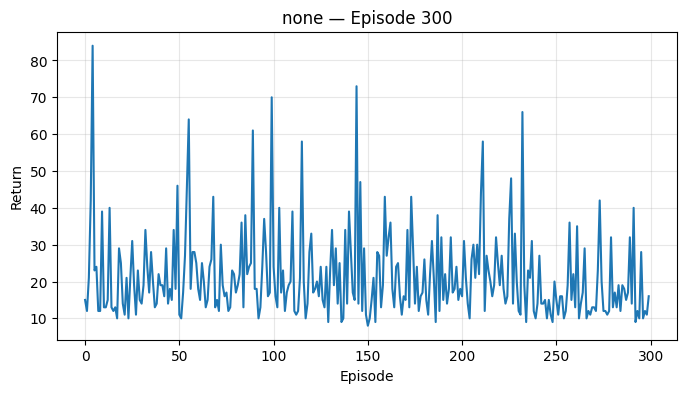

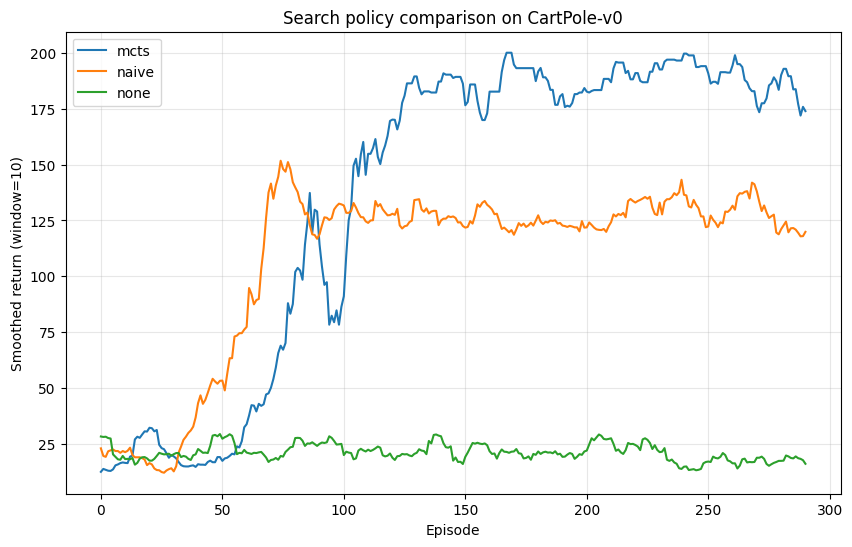

In [22]:
results = {}
for st in ["mcts", "naive", "none"]:
    print(f"\n=== Training agent with search_type = {st} ===")
    results[st] = train_agent(search_type=st, num_episodes=300, verbose=True)

plt.figure(figsize=(10, 6))
for st, returns in results.items():
    window = 10
    smoothed = np.convolve(returns, np.ones(window)/window, mode="valid")
    plt.plot(smoothed, label=st)
plt.title("Search policy comparison on CartPole-v0")
plt.xlabel("Episode")
plt.ylabel("Smoothed return (window=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 🔍 Discussion Questions *(answer in the markdown cell below)*

1. **Which search method converges fastest?** Why might that be?
2. **What is the wall-clock cost of MCTS vs. naive search vs. no search per episode?** How does this scale with the action space?
3. **What happens if you increase `num_simulations` for MCTS?** Is there a point of diminishing returns?
4. **Why does MuZero work even though the dynamics model is never trained to predict raw observations?**
5. **How would you modify this code to run on a more complex environment** (e.g., LunarLander or an Atari game)? Which components would need the most work?

---

### Your answers

1. MCTS converges fastest and it balances exploration and exploitation using PUCT and intelligently exploring promising actions while learning from simulated rollouts so it finds good strategies quicker than brute force search

2. 

none: Fastest - just one forward pass through the network

naive: Slowest - checks all possible action sequences (|A|^d combinations)

MCTS: Medium speed - explores promising branches only and not all of them

so naive search scales exponentially with action space (|A|^depth) while MCTS scales much better because it focuses on promising paths

3. more simulations means better decisions because the tree is explored more thoroughly but eventually you reach diminishing returns and after enough simulations the policy stabilizes and extra simulations give minimal improvement while taking much longer to run

4. MuZero learns a latent representation of the environment and the dynamics model only needs to predict future latent states and rewards and values so it doesn't need to reconstruct pixels or raw observations and this latent space is easier to learn and still captures everything needed for planning

5. 

representation network: would need CNNs instead of MLPs to process images (Atari) or larger MLPs for continuous states (LunarLander)

larger networks: more layers and neurons for complex environments

environment wrapper: to handle images/continuous actions

hyperparameter tuning: more simulations and larger batch sizes and different learning rates

Atari would also need frame stacking and preprocessing (grayscale and resizing)

## ✅ Submission Checklist

Before submitting, make sure:

- [ ] All `TODO` blocks are filled in.
- [ ] The networks (`RepresentationNet`, `DynamicsNet`, `PredictionNet`) instantiate without errors.
- [ ] `MCTS.run(...)` returns visit counts whose sum equals `num_simulations`.
- [ ] `naive_depth_search(...)` returns a valid action (`int`) and a finite value.
- [ ] `train_agent(search_type="mcts")` runs end-to-end and produces a non-trivial learning curve.
- [ ] All three search types are compared in the final plot.
- [ ] The discussion questions are answered.

Good luck! 🌳